### Imports and Device Setup

In [9]:
import os
import cv2
import json
import glob
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
from torchvision import models
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    f1_score, accuracy_score,
    confusion_matrix, classification_report
)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')


Using device: cuda


In [10]:
DATA_ROOT = '/kaggle/input/datasets/blossom1994/bdd-small-dataset/input'

TRAIN_LABEL_PATH = os.path.join(DATA_ROOT, 'annotation', 'trainlabels.json')
VAL_LABEL_PATH   = os.path.join(DATA_ROOT, 'annotation', 'vallabels.json')
TEST_LABEL_PATH  = os.path.join(DATA_ROOT, 'annotation', 'testlabels.json')

TRAIN_DIR = os.path.join(DATA_ROOT, 'bdd100k_image', 'train')
VAL_DIR   = os.path.join(DATA_ROOT, 'bdd100k_image', 'val')
TEST_DIR  = os.path.join(DATA_ROOT, 'bdd100k_image', 'test')


### Dataset and Dataloaders

In [11]:
# Training uses augmentation; val/test stay clean
train_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])


class BDDSmall2FrameDataset(Dataset):
    """
    Loads exactly 2 frames per sequence using the label JSON directly.
    Skips sequences that do not have exactly 2 frames.
    Returns: (frames_tensor, sequence_label, seq_name)
    """

    def __init__(self, image_root, label_json_path, transform=None):
        self.image_root = image_root

        with open(label_json_path, 'r') as f:
            self.labels = json.load(f)

        self.sequences = []
        skipped_count  = 0

        for seq_name, frames in self.labels.items():
            frame_files = sorted(
                frames.keys(),
                key=lambda x: int(x.split('_frame_')[1].split('.')[0])
            )
            if len(frame_files) == 2:
                self.sequences.append({
                    'seq_name':    seq_name,
                    'frame_files': frame_files
                })
            else:
                skipped_count += 1

        print(f'Loaded  {len(self.sequences)} sequences from {image_root}')
        print(f'Skipped {skipped_count} sequences (not exactly 2 frames)')

        self.transform = transform if transform is not None else val_transform

    def __len__(self):
        return len(self.sequences)

    def convert_labels(self, label_list):
        """6-label → 3-label: [red, green, sign]"""
        return [label_list[0], label_list[2], label_list[4]]

    def __getitem__(self, idx):
        seq_info    = self.sequences[idx]
        seq_name    = seq_info['seq_name']
        frame_files = seq_info['frame_files']

        frames      = []
        labels_list = []

        for frame_file in frame_files:
            img_path = os.path.join(self.image_root, seq_name, frame_file)
            img = cv2.imread(img_path)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            if self.transform:
                img = self.transform(img)
            frames.append(img)
            labels_list.append(self.convert_labels(self.labels[seq_name][frame_file]))

        frames_tensor  = torch.stack(frames)                                    # (2, 3, 224, 224)
        sequence_label = torch.tensor(labels_list[-1], dtype=torch.float32)    # last frame label
        return frames_tensor, sequence_label, seq_name


def create_dataloaders(batch_size=16, num_workers=2):
    train_dataset = BDDSmall2FrameDataset(TRAIN_DIR, TRAIN_LABEL_PATH, transform=train_transform)
    val_dataset   = BDDSmall2FrameDataset(VAL_DIR,   VAL_LABEL_PATH,   transform=val_transform)
    test_dataset  = BDDSmall2FrameDataset(TEST_DIR,  TEST_LABEL_PATH,  transform=val_transform)

    def collate_fn(batch):
        frames    = torch.stack([item[0] for item in batch])
        labels    = torch.stack([item[1] for item in batch])
        seq_names = [item[2] for item in batch]
        return frames, labels, seq_names

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True,
                              num_workers=num_workers, collate_fn=collate_fn)
    val_loader   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False,
                              num_workers=num_workers, collate_fn=collate_fn)
    test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False,
                              num_workers=num_workers, collate_fn=collate_fn)

    print(f'\nTrain batches: {len(train_loader)} | '
          f'Val batches: {len(val_loader)} | '
          f'Test batches: {len(test_loader)}')
    print(f'Batch shape: (B, 2, 3, 224, 224) | Label shape: (B, 3)')
    return train_loader, val_loader, val_dataset, test_loader


train_loader, val_loader, val_dataset, test_loader = create_dataloaders()


Loaded  1140 sequences from /kaggle/input/datasets/blossom1994/bdd-small-dataset/input/bdd100k_image/train
Skipped 220 sequences (not exactly 2 frames)
Loaded  224 sequences from /kaggle/input/datasets/blossom1994/bdd-small-dataset/input/bdd100k_image/val
Skipped 52 sequences (not exactly 2 frames)
Loaded  445 sequences from /kaggle/input/datasets/blossom1994/bdd-small-dataset/input/bdd100k_image/test
Skipped 110 sequences (not exactly 2 frames)

Train batches: 72 | Val batches: 14 | Test batches: 28
Batch shape: (B, 2, 3, 224, 224) | Label shape: (B, 3)


### GRU Model Architecture

In [12]:
class GRUTrafficClassifier(nn.Module):
    def __init__(self, hidden_dim=256, num_layers=2, num_classes=3, dropout=0.5):
        super().__init__()

        backbone = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)

        # Freeze all ResNet layers
        for param in backbone.parameters():
            param.requires_grad = False

        # Unfreeze layer3 and layer4 to adapt to driving footage
        for param in backbone.layer3.parameters():
            param.requires_grad = True
        for param in backbone.layer4.parameters():
            param.requires_grad = True

        self.feature_extractor = nn.Sequential(*list(backbone.children())[:-1])
        self.backbone = backbone

        self.gru = nn.GRU(
            input_size=2048, hidden_size=hidden_dim,
            num_layers=num_layers, batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Sequential(
            nn.Linear(hidden_dim, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        B, T, C, H, W = x.shape
        x        = x.view(B * T, C, H, W)
        features = self.feature_extractor(x)
        features = torch.flatten(features, 1).view(B, T, -1)
        gru_out, _ = self.gru(features)
        return self.fc(self.dropout(gru_out[:, -1, :]))


model = GRUTrafficClassifier(hidden_dim=256, num_layers=2, dropout=0.5).to(device)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total params:     {total_params:,}')
print(f'Trainable params: {trainable_params:,}')


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 220MB/s]


Total params:     27,756,075
Trainable params: 24,262,147


### Training Setup and Training Loop

In [13]:
# Weighted loss — inverse of class frequency: Red ~20%, Green ~26%, Sign ~59%
pos_weight = torch.tensor([4.0, 2.8, 1.0]).to(device)
criterion  = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

# Discriminative LRs: pretrained layers adapt slowly, new layers learn fast
optimizer = torch.optim.AdamW([
    {'params': model.backbone.layer3.parameters(), 'lr': 1e-4},
    {'params': model.backbone.layer4.parameters(), 'lr': 1e-4},
    {'params': model.gru.parameters(),             'lr': 1e-3},
    {'params': model.fc.parameters(),              'lr': 1e-3},
], weight_decay=1e-4)

scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.5)
epochs    = 30


In [14]:
def train_model(patience=7):
    best_f1, best_epoch, no_improve = 0.0, 0, 0
    train_loss_history = []
    val_loss_history   = []

    for epoch in range(epochs):
        # ── Training ──────────────────────────────────────────────────
        model.train()
        train_loss = 0
        for data, target, _ in train_loader:          # unpack seq_names as _
            data, target = data.to(device), target.to(device)
            optimizer.zero_grad()
            loss = criterion(model(data), target)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        scheduler.step()

        # ── Validation ────────────────────────────────────────────────
        model.eval()
        val_loss = 0
        all_preds, all_targets = [], []

        with torch.no_grad():
            for data, target, _ in val_loader:        # unpack seq_names as _
                data, target = data.to(device), target.to(device)
                output = model(data)
                val_loss += criterion(output, target).item()
                preds = (torch.sigmoid(output) > 0.5).float()
                all_preds.append(preds.cpu().numpy())
                all_targets.append(target.cpu().numpy())

        all_preds   = np.vstack(all_preds)
        all_targets = np.vstack(all_targets)

        train_loss_history.append(train_loss / len(train_loader))
        val_loss_history.append(val_loss / len(val_loader))

        avg_acc = np.mean([
            accuracy_score(all_targets[:, i], all_preds[:, i])
            for i in range(all_targets.shape[1])
        ])
        f1 = f1_score(all_targets, all_preds, average='macro', zero_division=0)
        current_lr = scheduler.get_last_lr()[0]

        print(
            f'Epoch {epoch+1:2d}/{epochs} | '
            f'Train Loss: {train_loss_history[-1]:.4f} | '
            f'Val Loss: {val_loss_history[-1]:.4f} | '
            f'Val Avg Acc: {avg_acc:.4f} | '
            f'Val F1 (macro): {f1:.4f} | '
            f'LR: {current_lr:.6f}'
        )

        # ── Checkpoint ────────────────────────────────────────────────
        if f1 > best_f1:
            best_f1, best_epoch, no_improve = f1, epoch + 1, 0
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'val_f1': best_f1,
            }, 'best_model.pth')
            print(f'  -> Best model saved (F1: {best_f1:.4f})')
        else:
            no_improve += 1
            print(f'  -> No improvement. Patience: {no_improve}/{patience}')
            if no_improve >= patience:
                print(f'\nEarly stopping at epoch {epoch+1}')
                break

    print(f'\nBest model: epoch {best_epoch} | Val F1: {best_f1:.4f}')
    model.load_state_dict(torch.load('best_model.pth')['model_state_dict'])
    return train_loss_history, val_loss_history, best_epoch


train_loss_history, val_loss_history, best_epoch = train_model()


Epoch  1/30 | Train Loss: 0.9259 | Val Loss: 0.9672 | Val Avg Acc: 0.5476 | Val F1 (macro): 0.5953 | LR: 0.000100
  -> Best model saved (F1: 0.5953)
Epoch  2/30 | Train Loss: 0.8354 | Val Loss: 0.9027 | Val Avg Acc: 0.6711 | Val F1 (macro): 0.6498 | LR: 0.000100
  -> Best model saved (F1: 0.6498)
Epoch  3/30 | Train Loss: 0.7787 | Val Loss: 0.8756 | Val Avg Acc: 0.6741 | Val F1 (macro): 0.6311 | LR: 0.000100
  -> No improvement. Patience: 1/7
Epoch  4/30 | Train Loss: 0.7141 | Val Loss: 1.0852 | Val Avg Acc: 0.6890 | Val F1 (macro): 0.6403 | LR: 0.000100
  -> No improvement. Patience: 2/7
Epoch  5/30 | Train Loss: 0.6445 | Val Loss: 0.8142 | Val Avg Acc: 0.6830 | Val F1 (macro): 0.6581 | LR: 0.000100
  -> Best model saved (F1: 0.6581)
Epoch  6/30 | Train Loss: 0.6072 | Val Loss: 0.7688 | Val Avg Acc: 0.7530 | Val F1 (macro): 0.7277 | LR: 0.000100
  -> Best model saved (F1: 0.7277)
Epoch  7/30 | Train Loss: 0.6025 | Val Loss: 0.7705 | Val Avg Acc: 0.7589 | Val F1 (macro): 0.7066 | LR: 0

### Testing

TEST RESULTS
  Red Light    Accuracy: 0.8292
  Green Light  Accuracy: 0.6787
  Road Sign    Accuracy: 0.6719

  Avg Label Accuracy : 0.7266
  Exact Match Acc    : 0.3978
  Macro F1           : 0.6943

              precision    recall  f1-score   support

   Red Light       0.76      0.73      0.74       152
 Green Light       0.42      0.73      0.53       113
   Road Sign       0.67      1.00      0.80       299

   micro avg       0.63      0.87      0.73       564
   macro avg       0.62      0.82      0.69       564
weighted avg       0.65      0.87      0.73       564
 samples avg       0.62      0.71      0.64       564



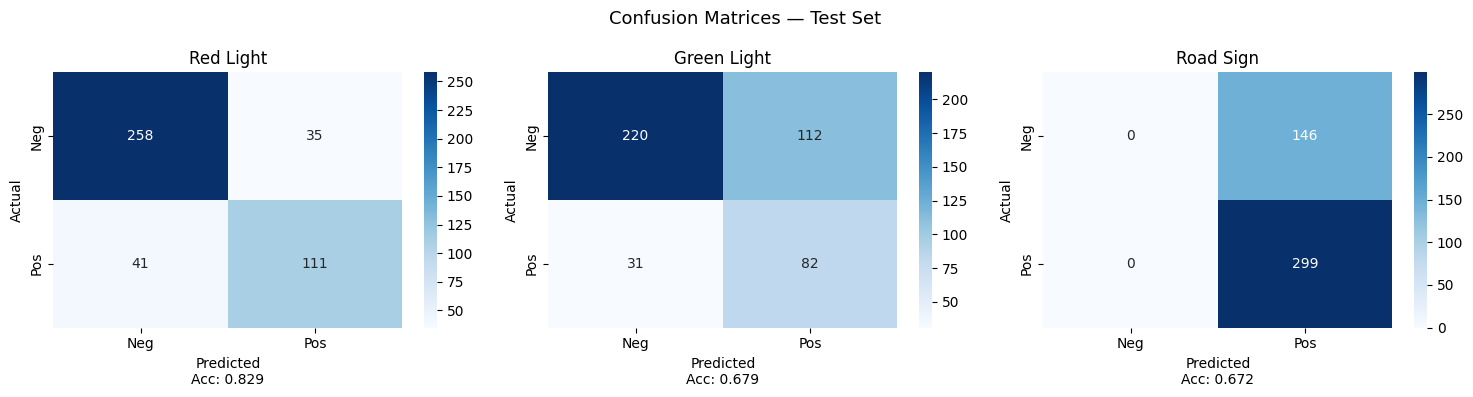

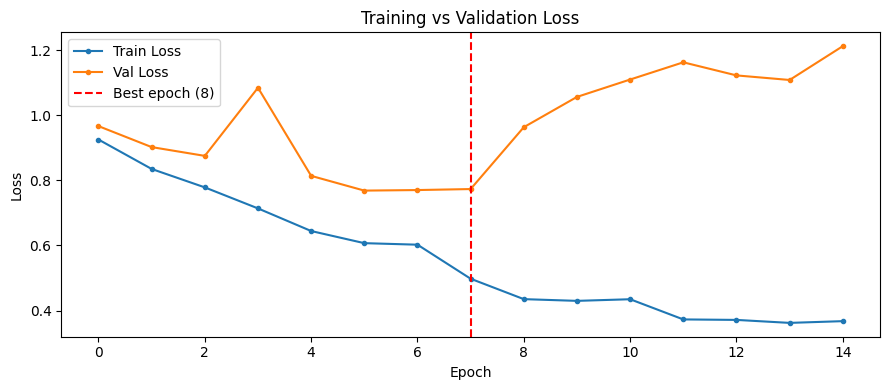

In [15]:
def test_model(train_loss_history, val_loss_history, best_epoch):
    # ── Inference on test set ──────────────────────────────────────────
    model.eval()
    all_preds, all_targets = [], []

    with torch.no_grad():
        for data, target, _ in test_loader:   # unpack seq_names as _
            data, target = data.to(device), target.to(device)
            preds = (torch.sigmoid(model(data)) > 0.5).float()
            all_preds.append(preds.cpu().numpy())
            all_targets.append(target.cpu().numpy())

    all_preds   = np.vstack(all_preds)
    all_targets = np.vstack(all_targets)
    class_names = ['Red Light', 'Green Light', 'Road Sign']

    # ── Metrics ───────────────────────────────────────────────────────
    print('=' * 55)
    print('TEST RESULTS')
    print('=' * 55)
    for i, name in enumerate(class_names):
        acc = accuracy_score(all_targets[:, i], all_preds[:, i])
        print(f'  {name:12s} Accuracy: {acc:.4f}')

    avg_acc     = np.mean([accuracy_score(all_targets[:, i], all_preds[:, i]) for i in range(3)])
    exact_match = (all_preds == all_targets).all(axis=1).mean()
    f1_mac      = f1_score(all_targets, all_preds, average='macro', zero_division=0)

    print(f'\n  Avg Label Accuracy : {avg_acc:.4f}')
    print(f'  Exact Match Acc    : {exact_match:.4f}')
    print(f'  Macro F1           : {f1_mac:.4f}')
    print('\n' + classification_report(
        all_targets, all_preds, target_names=class_names, zero_division=0
    ))

    # ── Confusion matrices (one per class) ────────────────────────────
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    for i, name in enumerate(class_names):
        cm = confusion_matrix(all_targets[:, i], all_preds[:, i])
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                    xticklabels=['Neg', 'Pos'], yticklabels=['Neg', 'Pos'])
        axes[i].set_title(name)
        acc = accuracy_score(all_targets[:, i], all_preds[:, i])
        axes[i].set_xlabel(f'Predicted\nAcc: {acc:.3f}')
        axes[i].set_ylabel('Actual')
    plt.suptitle('Confusion Matrices — Test Set', fontsize=13)
    plt.tight_layout()
    plt.show()

    # ── Loss curve ────────────────────────────────────────────────────
    plt.figure(figsize=(9, 4))
    plt.plot(train_loss_history, label='Train Loss', marker='o', markersize=3)
    plt.plot(val_loss_history,   label='Val Loss',   marker='o', markersize=3)
    plt.axvline(x=best_epoch - 1, color='red', linestyle='--',
                label=f'Best epoch ({best_epoch})')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training vs Validation Loss')
    plt.legend()
    plt.tight_layout()
    plt.show()


test_model(train_loss_history, val_loss_history, best_epoch)


### Inference and Visualization

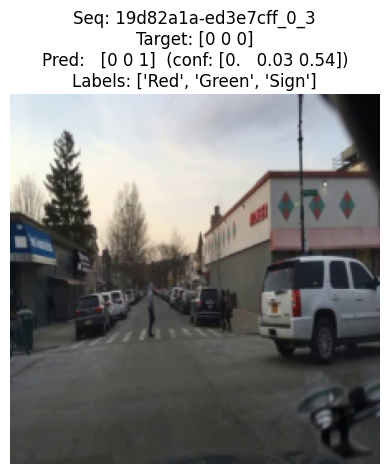

In [16]:
def predict_sequence(dataset_idx):
    model.eval()
    with torch.no_grad():
        frames, label, seq_name = val_dataset[dataset_idx]  # 3-item unpack
        input_tensor = frames.unsqueeze(0).to(device)
        output       = model(input_tensor)
        prediction   = torch.sigmoid(output).cpu().numpy()[0]

    # Denormalize first frame for display
    mean  = torch.tensor([0.485, 0.456, 0.406])
    std   = torch.tensor([0.229, 0.224, 0.225])
    frame = frames[0] * std[:, None, None] + mean[:, None, None]
    frame = frame.permute(1, 2, 0).clamp(0, 1).numpy()

    label_names = ['Red', 'Green', 'Sign']
    pred_binary = (prediction > 0.5).astype(int)

    plt.imshow(frame)
    plt.title(
        f'Seq: {seq_name}\n'
        f'Target: {label.numpy().astype(int)}\n'
        f'Pred:   {pred_binary}  (conf: {np.round(prediction, 2)})\n'
        f'Labels: {label_names}'
    )
    plt.axis('off')
    plt.show()


predict_sequence(0)
